In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Convert Churn to numeric for correlation
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


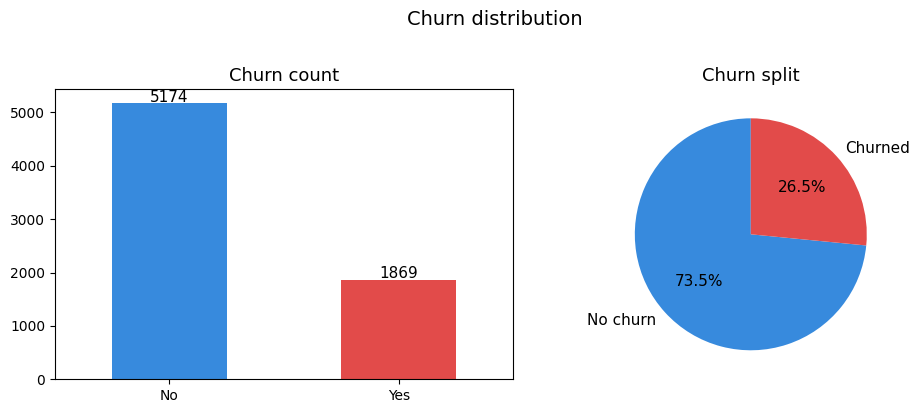

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ['#378ADD', '#E24B4A']

# Count
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='none')
axes[0].set_title('Churn count', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height())}', ha='center', fontsize=11)

# Percentage
sizes = df['Churn'].value_counts()
axes[1].pie(sizes, labels=['No churn', 'Churned'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Churn split', fontsize=13)

plt.suptitle('Churn distribution', fontsize=14, fontweight='500', y=1.02)
plt.tight_layout()
plt.savefig('chart_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

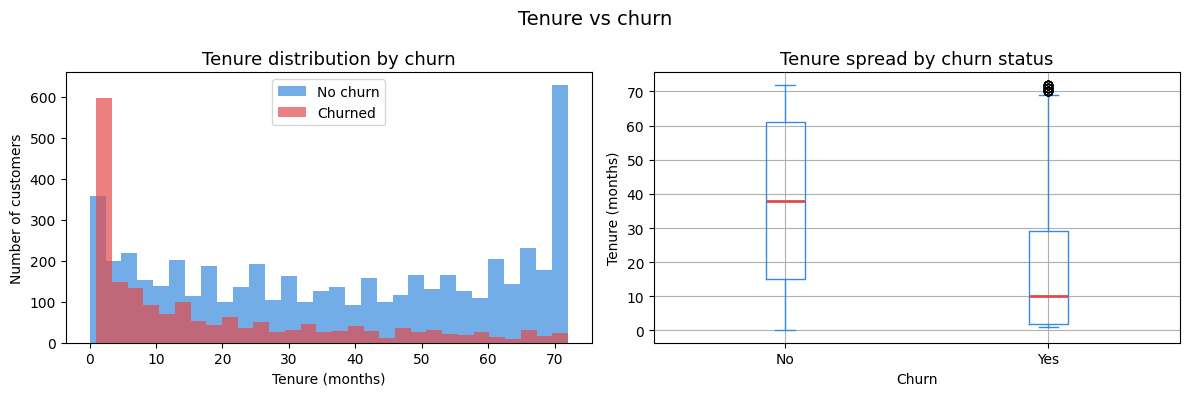

Average tenure — Churned:     18.0 months
Average tenure — Not churned: 37.6 months


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram: tenure distribution by churn status
churned     = df[df['Churn'] == 'Yes']['tenure']
not_churned = df[df['Churn'] == 'No']['tenure']

axes[0].hist(not_churned, bins=30, alpha=0.7, color='#378ADD', label='No churn')
axes[0].hist(churned,     bins=30, alpha=0.7, color='#E24B4A', label='Churned')
axes[0].set_title('Tenure distribution by churn', fontsize=13)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of customers')
axes[0].legend()

# Boxplot: tenure spread
df.boxplot(column='tenure', by='Churn', ax=axes[1],
           boxprops=dict(color='#378ADD'),
           medianprops=dict(color='#E24B4A', linewidth=2),
           whiskerprops=dict(color='#378ADD'),
           capprops=dict(color='#378ADD'))
axes[1].set_title('Tenure spread by churn status', fontsize=13)
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (months)')
plt.suptitle('')

plt.suptitle('Tenure vs churn', fontsize=14, fontweight='500')
plt.tight_layout()
plt.savefig('chart_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average tenure — Churned:     {churned.mean():.1f} months")
print(f"Average tenure — Not churned: {not_churned.mean():.1f} months")

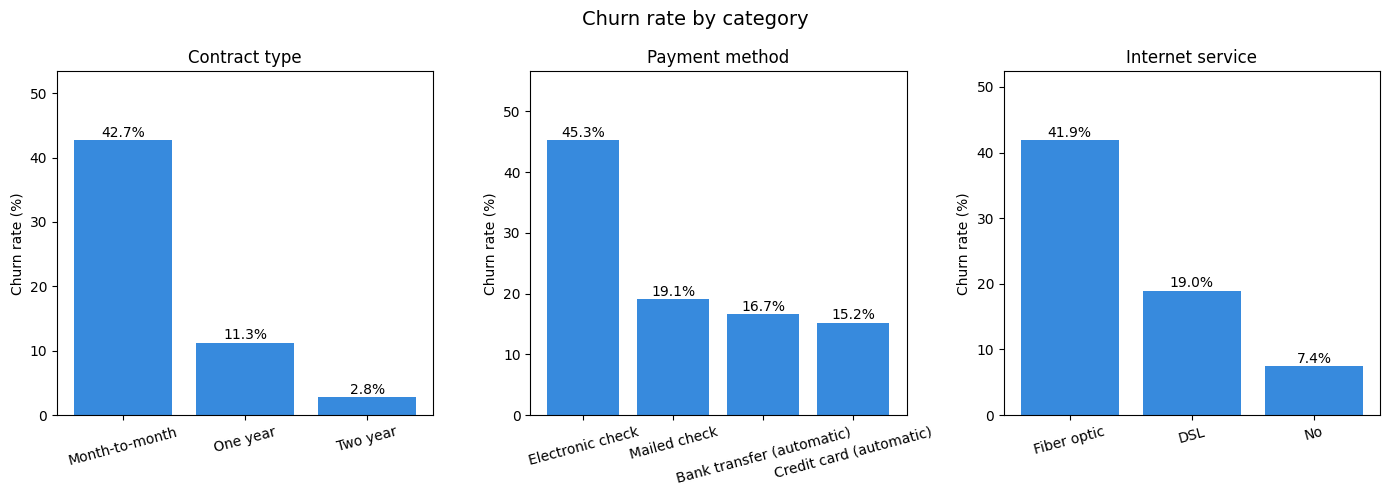

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

cat_cols = ['Contract', 'PaymentMethod', 'InternetService']
titles   = ['Contract type', 'Payment method', 'Internet service']

for ax, col, title in zip(axes, cat_cols, titles):
    churn_rate = df.groupby(col)['Churn_num'].mean().mul(100).sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values, color='#378ADD', edgecolor='none')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Churn rate (%)')
    ax.set_ylim(0, churn_rate.max() * 1.25)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=10)

plt.suptitle('Churn rate by category', fontsize=14, fontweight='500')
plt.tight_layout()
plt.savefig('chart_categories.png', dpi=150, bbox_inches='tight')
plt.show()

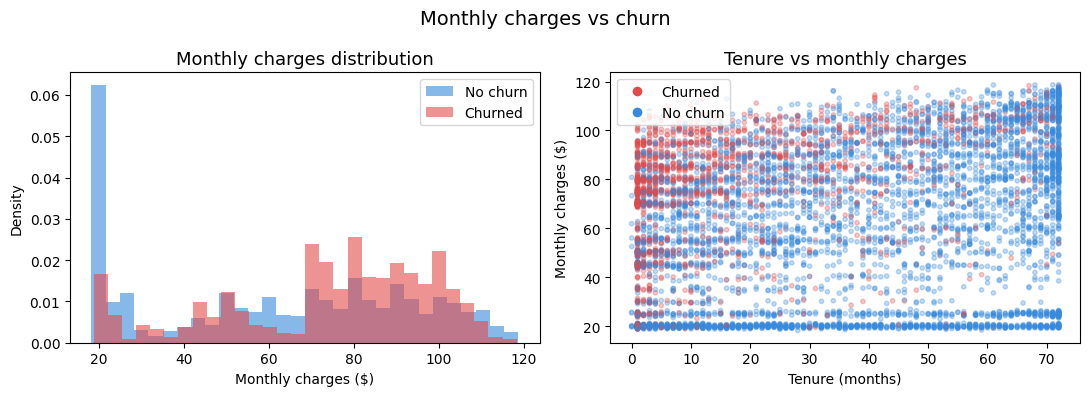

Avg monthly charges — Churned:     $74.44
Avg monthly charges — Not churned: $61.27


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# KDE plot
for label, color in [('No', '#378ADD'), ('Yes', '#E24B4A')]:
    subset = df[df['Churn'] == label]['MonthlyCharges']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color,
                 label=f'{"Churned" if label=="Yes" else "No churn"}', density=True)
axes[0].set_title('Monthly charges distribution', fontsize=13)
axes[0].set_xlabel('Monthly charges ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Scatter: tenure vs monthly charges, colored by churn
colors_map = df['Churn'].map({'No': '#378ADD', 'Yes': '#E24B4A'})
axes[1].scatter(df['tenure'], df['MonthlyCharges'],
                c=colors_map, alpha=0.3, s=10)
axes[1].set_title('Tenure vs monthly charges', fontsize=13)
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Monthly charges ($)')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A', markersize=8, label='Churned'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='#378ADD', markersize=8, label='No churn')]
axes[1].legend(handles=legend_elements)

plt.suptitle('Monthly charges vs churn', fontsize=14, fontweight='500')
plt.tight_layout()
plt.savefig('chart_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg monthly charges — Churned:     ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"Avg monthly charges — Not churned: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

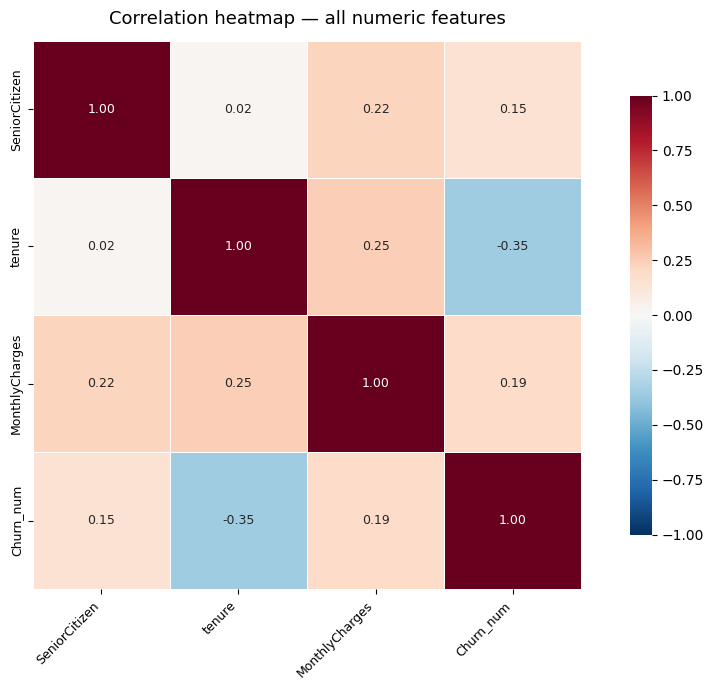


Top features correlated with churn:
tenure           -0.352
MonthlyCharges    0.193
SeniorCitizen     0.151
Name: Churn_num, dtype: float64


In [7]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix  = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})

plt.title('Correlation heatmap — all numeric features', fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('chart_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with Churn
print("\nTop features correlated with churn:")
print(corr_matrix['Churn_num'].drop('Churn_num').sort_values(key=abs, ascending=False).round(3))

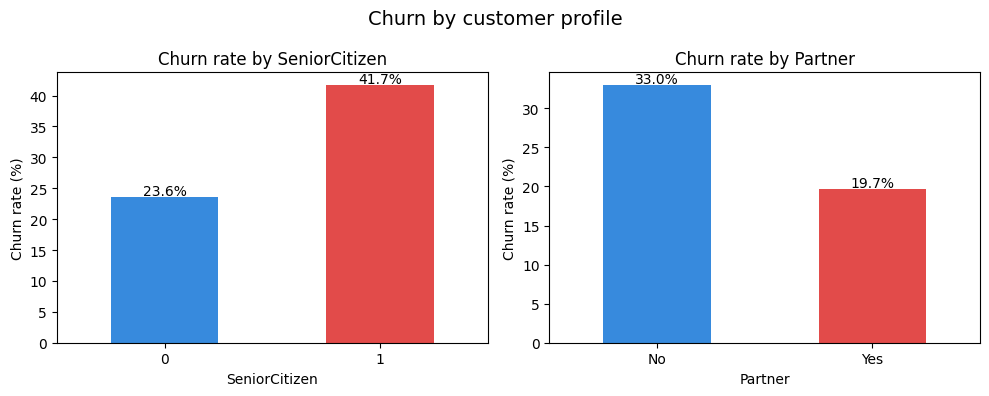

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

binary_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService']

churn_rates = {col: df.groupby(col)['Churn_num'].mean().mul(100) for col in binary_cols}

for i, (col, rates) in enumerate(list(churn_rates.items())[:2]):
    rates.plot(kind='bar', ax=axes[i], color=['#378ADD','#E24B4A'], edgecolor='none')
    axes[i].set_title(f'Churn rate by {col}', fontsize=12)
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].tick_params(rotation=0)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.suptitle('Churn by customer profile', fontsize=14, fontweight='500')
plt.tight_layout()
plt.savefig('chart_profile.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print("=" * 50)
print("EDA KEY FINDINGS SUMMARY")
print("=" * 50)

total        = len(df)
churned      = df['Churn_num'].sum()
churn_rate   = churned / total * 100

print(f"\nTotal customers:  {total:,}")
print(f"Churned:          {churned:,} ({churn_rate:.1f}%)")
print(f"Retained:         {total - churned:,} ({100 - churn_rate:.1f}%)")

print("\nAvg tenure:")
print(f"  Churned:     {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"  Retained:    {df[df['Churn']=='No']['tenure'].mean():.1f} months")

print("\nChurn rate by contract:")
print(df.groupby('Contract')['Churn_num'].mean().mul(100).round(1).astype(str) + '%')

print("\nTop 3 churn drivers (by correlation):")
top3 = corr_matrix['Churn_num'].drop('Churn_num').sort_values(key=abs, ascending=False).head(3)
for feat, val in top3.items():
    direction = 'increases' if val > 0 else 'decreases'
    print(f"  {feat}: r={val:.3f} — higher value {direction} churn risk")

EDA KEY FINDINGS SUMMARY

Total customers:  7,043
Churned:          1,869 (26.5%)
Retained:         5,174 (73.5%)

Avg tenure:
  Churned:     18.0 months
  Retained:    37.6 months

Churn rate by contract:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn_num, dtype: object

Top 3 churn drivers (by correlation):
  tenure: r=-0.352 — higher value decreases churn risk
  MonthlyCharges: r=0.193 — higher value increases churn risk
  SeniorCitizen: r=0.151 — higher value increases churn risk
